In [1]:
# CELL 1 — INSTALLS
!pip -q install pillow-heif facenet-pytorch pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 48.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 60.5 MB/s eta 0:00:00


In [2]:
# CELL 2 — IMPORTS AND CONFIG
import os, io, csv, gc, copy, random, hashlib
from pathlib import Path
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from pillow_heif import register_heif_opener
register_heif_opener(); ImageFile.LOAD_TRUNCATED_IMAGES=True

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b3
from facenet_pytorch import MTCNN
import pyarrow.parquet as pq

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
PIN_MEMORY=torch.cuda.is_available(); NUM_WORKERS=0
TARGET_SIZE=224; RESIZE_SIZE=256; FFT_CLIP_MAX=14.0
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
IMG_EXTS={'.jpg','.jpeg','.png','.webp','.bmp','.heic','.heif'}

FREQ_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model.pth')
ORIGINAL_SPATIAL_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth')
AUXILIARY_HEAD_CKPT=Path('/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/spatial_auxiliary_multitask_head.pth')
STYLEGAN_ROOT=Path('/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train')
FLICKR_ROOT=Path('/kaggle/input/datasets/adityajn105/flickr30k/Images/flickr30k_images')
DEEPDETECT_ROOT=Path('/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train')
FF_SPLIT_ROOT=Path('/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split')
PHONE_ROOT=Path('/kaggle/input/datasets/kashirhanif/phone-images')
CELEB_ROOT=Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2')
OPENFAKE_DIRS=[Path(f'/kaggle/input/datasets/kashirhanif/openfake-part-{i}') for i in range(1,5)]
OPENFAKE_ROOT=Path('/kaggle/working/of_imgs'); OPENFAKE_MANIFEST=Path('/kaggle/working/of_manifest.csv')
OPENFAKE_PER_GENERATOR=1000
CAPS={'stylegan_real':25000,'stylegan_fake':25000,'flickr_real':15000,'deepdetect_fake':15000,'openfake_per_source':1000}
PHONE_TRAIN_RATIO=.60; PHONE_VAL_RATIO=.20
CELEB_REAL_CAP=10000; CELEB_FAKE_CAP=20000
FUSION_BATCH_SIZE=384; FUSION_EPOCHS=40; FUSION_LR=3e-4; FUSION_WEIGHT_DECAY=1e-4; FUSION_PATIENCE=7
PROJECTION_DIM=48; UNCERTAIN_LOW=.30; UNCERTAIN_HIGH=.70
OUTPUT_DIR=Path('/kaggle/working');CACHE_PATH = Path(
    "/kaggle/input/datasets/kashirhanif/"
    "frequency-model-checkpoint/"
    "heterogeneous_multiview_features.pt"
)
print('Device:',DEVICE)

Device: cuda


In [3]:
# CELL 3 — PATH CHECK
required={'frequency checkpoint':FREQ_CKPT,'spatial checkpoint':ORIGINAL_SPATIAL_CKPT,'auxiliary checkpoint':AUXILIARY_HEAD_CKPT,
          'StyleGAN':STYLEGAN_ROOT,'Flickr':FLICKR_ROOT,'DeepDetect':DEEPDETECT_ROOT,'FF++':FF_SPLIT_ROOT,
          'Phone':PHONE_ROOT,'CelebDF':CELEB_ROOT}
for name,path in required.items(): print(f'{name:<28}', 'OK' if path.exists() else 'MISSING', path)
missing=[name for name,path in required.items() if not path.exists()]
if missing: raise FileNotFoundError('Update paths in Cell 2: '+', '.join(missing))

frequency checkpoint         OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model.pth
spatial checkpoint           OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth
auxiliary checkpoint         OK /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/spatial_auxiliary_multitask_head.pth
StyleGAN                     OK /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train
Flickr                       OK /kaggle/input/datasets/adityajn105/flickr30k/Images/flickr30k_images
DeepDetect                   OK /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train
FF++                         OK /kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split
Phone                        OK /kaggle/input/datasets/kashirhanif/phone-images
CelebDF                      OK /kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2


In [4]:

# CELL 4 — REFERENCES AND SAFE HELPERS


from dataclasses import dataclass
from collections import defaultdict, Counter

@dataclass(frozen=True)
class SampleRef:
    path: str
    label: int
    source: str
    scenario: str
    spatial_mode: str      # already_face | detect | unavailable
    group: str = ""


def list_images(root: Path):
    if not root.exists():
        return []

    return sorted([
        p
        for p in root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMG_EXTS
    ])


def validate_image(path: Path):
    try:
        with Image.open(path) as image:
            image.load()
            image.convert("RGB")
        return True, ""
    except Exception as exc:
        return False, str(exc)


def cap_shuffle(paths, cap=None, seed=SEED):
    paths = list(paths)
    random.Random(seed).shuffle(paths)

    if cap is None:
        return paths

    return paths[:cap]


def group_key(path: Path):
    tokens = path.stem.replace("-", "_").split("_")

    if len(tokens) >= 2:
        return "_".join(tokens[:2])

    return path.stem


def make_refs(paths, label, source, scenario, spatial_mode):
    return [
        SampleRef(
            path=str(path),
            label=label,
            source=source,
            scenario=scenario,
            spatial_mode=spatial_mode,
            group=group_key(path),
        )
        for path in paths
    ]


def split_grouped_by_count(
    refs,
    train_ratio,
    val_ratio,
    seed=SEED,
):
    groups = defaultdict(list)

    for ref in refs:
        groups[ref.group].append(ref)

    items = list(groups.items())

    random.Random(seed).shuffle(items)

    items.sort(
        key=lambda x: len(x[1]),
        reverse=True,
    )

    total = len(refs)

    targets = {
        "train": int(total * train_ratio),
        "val": int(total * val_ratio),
        "test": (
            total
            - int(total * train_ratio)
            - int(total * val_ratio)
        ),
    }

    result = {
        "train": [],
        "val": [],
        "test": [],
    }

    for _, group_refs in items:

        deficits = {
            split: (
                targets[split]
                - len(result[split])
            )
            for split in result
        }

        chosen_split = max(
            result,
            key=lambda split:
                deficits[split]
                / max(targets[split], 1),
        )

        result[chosen_split].extend(group_refs)

    return result


def summarize(name, refs):

    print()
    print(f"{name}: {len(refs):,}")

    print(
        "labels:",
        Counter(r.label for r in refs),
    )

    print(
        "scenarios:",
        Counter(r.scenario for r in refs),
    )

    print(
        "spatial modes:",
        Counter(r.spatial_mode for r in refs),
    )

    print(
        "sources:",
        Counter(r.source for r in refs).most_common(12),
    )

In [5]:
# CELL 5 — LOAD THREE EXPERTS 
def trusted_load(path): return torch.load(path,map_location='cpu',weights_only=False)
def build_binary_efficientnet():
    m=efficientnet_b3(weights=None); n=m.classifier[1].in_features
    m.classifier=nn.Sequential(nn.Dropout(.3,inplace=True),nn.Linear(n,1)); return m

def unpack_state_dict(x):
    if not isinstance(x,dict): return x
    for k in ('model_state_dict','state_dict','model'):
        if k in x and isinstance(x[k],dict): return x[k]
    return x

def clean_state_dict(state):
    out={}
    for k,v in state.items():
        for prefix in ('module.','model.'):
            if k.startswith(prefix): k=k[len(prefix):]
        out[k]=v
    return out

def load_binary(path):
    m=build_binary_efficientnet(); ck=trusted_load(path); m.load_state_dict(clean_state_dict(unpack_state_dict(ck)),strict=True)
    m.to(DEVICE).eval(); [p.requires_grad_(False) for p in m.parameters()]; return m

class SpatialAuxiliaryHead(nn.Module):
    def __init__(self,input_dim,num_classes):
        super().__init__(); self.shared_trunk=nn.Sequential(nn.Linear(input_dim,512),nn.BatchNorm1d(512),nn.GELU(),nn.Dropout(.35),nn.Linear(512,128),nn.BatchNorm1d(128),nn.GELU(),nn.Dropout(.2)); self.binary_head=nn.Linear(128,1); self.auxiliary_head=nn.Linear(128,num_classes)
    def forward(self,x):
        z=self.shared_trunk(x); return {'binary_logit':self.binary_head(z).squeeze(1),'auxiliary_logits':self.auxiliary_head(z)}

freq_model=load_binary(FREQ_CKPT); original_spatial_model=load_binary(ORIGINAL_SPATIAL_CKPT)
freq_backbone=copy.deepcopy(freq_model); freq_backbone.classifier=nn.Identity(); freq_backbone.eval()
spatial_backbone=copy.deepcopy(original_spatial_model); spatial_backbone.classifier=nn.Identity(); spatial_backbone.eval()
aux_ck=trusted_load(AUXILIARY_HEAD_CKPT); aux_dim=int(aux_ck.get('embedding_dim',1536)); aux_names=aux_ck.get('aux_class_names',['real','fake']); aux_n=int(aux_ck.get('num_aux_classes',len(aux_names)))
aux_model=SpatialAuxiliaryHead(aux_dim,aux_n); aux_state=aux_ck.get('model_state_dict',aux_ck.get('state_dict'))
if aux_state is None: raise KeyError(f'No aux state dict. Keys={list(aux_ck)}')
aux_model.load_state_dict(clean_state_dict(aux_state),strict=True); aux_model.to(DEVICE).eval(); [p.requires_grad_(False) for p in aux_model.parameters()]
aux_mean=torch.nan_to_num(torch.as_tensor(aux_ck['feature_mean']).float(),nan=0,posinf=0,neginf=0)
aux_std=torch.nan_to_num(torch.as_tensor(aux_ck['feature_std']).float(),nan=1,posinf=1,neginf=1).clamp_min(1e-6)
print('Experts loaded.')

Experts loaded.


In [6]:
# CELL 6 — FULL-IMAGE FREQUENCY VIEW + FACE-LOCAL SPATIAL VIEW
spatial_transform=transforms.Compose([transforms.Resize((RESIZE_SIZE,RESIZE_SIZE)),transforms.CenterCrop(TARGET_SIZE),transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])

def preprocess_frequency_full(image):
    image=image.convert('RGB').resize((RESIZE_SIZE,RESIZE_SIZE),Image.Resampling.BICUBIC); o=(RESIZE_SIZE-TARGET_SIZE)//2; image=image.crop((o,o,o+TARGET_SIZE,o+TARGET_SIZE))
    arr=np.asarray(image,dtype=np.float32)/255.; x=torch.from_numpy(arr).permute(2,0,1); out=[]
    for c in x:
        f=torch.fft.fftshift(torch.fft.fft2(c)); mag=torch.log1p(torch.abs(f)); out.append(torch.clamp(mag,0,FFT_CLIP_MAX)/FFT_CLIP_MAX)
    return torch.stack(out)

mtcnn=MTCNN(keep_all=True,device=DEVICE,min_face_size=24,thresholds=[.6,.7,.7],post_process=False)

def square_crop(image,box,margin=.25):
    W,H=image.size; x1,y1,x2,y2=map(float,box); bw,bh=x2-x1,y2-y1; side=max(bw,bh)*(1+2*margin); cx,cy=(x1+x2)/2,(y1+y2)/2
    l=max(0,int(cx-side/2)); t=max(0,int(cy-side/2)); r=min(W,int(cx+side/2)); b=min(H,int(cy+side/2)); return image.crop((l,t,r,b))

def get_spatial_view(image,mode):
    if mode=='already_face': return {'crop':image,'found':1.,'confidence':1.,'count':1.,'area_ratio':1.}
    if mode=='unavailable': return {'crop':None,'found':0.,'confidence':0.,'count':0.,'area_ratio':0.}
    boxes,probs=mtcnn.detect(image)
    if boxes is None or len(boxes)==0: return {'crop':None,'found':0.,'confidence':0.,'count':0.,'area_ratio':0.}
    areas=np.array([(b[2]-b[0])*(b[3]-b[1]) for b in boxes]); i=int(areas.argmax())
    return {'crop':square_crop(image,boxes[i]),'found':1.,'confidence':float(probs[i]),'count':float(len(boxes)),'area_ratio':float(areas[i]/max(image.width*image.height,1))}

def quality_features(image):
    g=np.asarray(image.convert('L').resize((224,224)),dtype=np.float32)/255.; gx=np.diff(g,axis=1); gy=np.diff(g,axis=0)
    return np.array([g.mean(),g.std(),(gx.var()+gy.var())/2,(g<.1).mean(),(g>.9).mean(),image.width/max(image.height,1)],dtype=np.float32)

In [ ]:
# CELL 7 — EXTRACT OPENFAKE FROM PARQUET IN CURRENT SESSION
GENERATORS=['sd-3.5','sd-2.1','flux.1-dev','sdxl-epic-realism','midjourney-6','gpt-image-1','sdxl','sd-1.5-dreamshaper','flux.1-schnell','dalle-3','sdxl-touchofrealism','flux-1.1-pro','sdxl-realvis-v5','ideogram-3.0','hidream-i1-full','sdxl-juggernaut','sd-1.5-epicdream','sd-1.5','flux-mvc5000','mystic','imagen-4.0','grok-2-image-1212','chroma','flux-amateursnapshotphotos','imagen-3.0-002','midjourney-7','flux-realism','recraft-v3','lumina-17-2-25','recraft-v2','aurora-20-1-25','ideogram-2.0','frames-23-1-25']

def extract_openfake(force=False):
    if OPENFAKE_MANIFEST.exists() and not force: print('Using',OPENFAKE_MANIFEST); return
    files=sorted({p for root in OPENFAKE_DIRS if root.exists() for p in root.rglob('*.parquet')})
    if not files: raise FileNotFoundError('Attach OpenFake parts 1-4.')
    OPENFAKE_ROOT.mkdir(parents=True,exist_ok=True); quotas={g:OPENFAKE_PER_GENERATOR for g in GENERATORS}; quotas['real']=OPENFAKE_PER_GENERATOR*len(GENERATORS); written=Counter(); rows=[]; idx=0
    for fp in tqdm(files,desc='Extract OpenFake'):
        if all(written[k]>=v for k,v in quotas.items()): break
        try:
            meta=pq.read_table(fp,columns=['label','model']); labels=meta['label'].to_pylist(); models=meta['model'].to_pylist()
        except Exception: continue
        wanted=[]
        for i,(lab,model) in enumerate(zip(labels,models)):
            real=str(lab).strip().lower()=='real'; src='real' if real else str(model).strip()
            if src in quotas and written[src]<quotas[src]: wanted.append((i,src,0 if real else 1))
        del meta,labels,models; gc.collect()
        if not wanted: continue
        try: table=pq.read_table(fp,columns=['image']); images=table['image']
        except Exception: continue
        for row_i,src,label in wanted:
            if written[src]>=quotas[src]: continue
            try:
                raw=images[row_i].as_py(); raw=raw.get('bytes') if isinstance(raw,dict) else raw
                if raw is None: continue
                with Image.open(io.BytesIO(raw)) as im:
                    im=im.convert('RGB'); folder=OPENFAKE_ROOT/src.replace('/','_'); folder.mkdir(parents=True,exist_ok=True); path=folder/f'{idx:08d}.jpg'; im.save(path,'JPEG',quality=88)
                rows.append({'path':str(path),'label':label,'source':src}); written[src]+=1; idx+=1
            except Exception: continue
        del images,table; gc.collect()
    pd.DataFrame(rows).to_csv(OPENFAKE_MANIFEST,index=False); print('OpenFake extracted',len(rows))
extract_openfake(False)

Extract OpenFake:   0%|          | 0/89 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


OpenFake extracted 62639


In [8]:
# CELL 8 — BUILD SOURCE/GROUP-AWARE SPLITS
train_refs=[]; val_refs=[]; mixed_test_refs=[]
def add_source(paths,label,source,scenario,mode,cap,seed):
    split=split_grouped_by_count(make_refs(cap_shuffle(paths,cap,seed),label,source,scenario,mode),.70,.15,seed)
    train_refs.extend(split['train']); val_refs.extend(split['val']); mixed_test_refs.extend(split['test'])

add_source(list_images(STYLEGAN_ROOT/'real'),0,'stylegan_real','clean_real','already_face',CAPS['stylegan_real'],SEED+1)
add_source(list_images(STYLEGAN_ROOT/'fake'),1,'stylegan_fake','ai_fake','already_face',CAPS['stylegan_fake'],SEED+2)
add_source(list_images(DEEPDETECT_ROOT/'fake'),1,'deepdetect_fake','ai_fake','already_face',CAPS['deepdetect_fake'],SEED+3)
add_source(list_images(FLICKR_ROOT),0,'flickr_real','clean_real','detect',CAPS['flickr_real'],SEED+4)

of=pd.read_csv(OPENFAKE_MANIFEST)
for src in sorted(of.source.unique()):
    sub=of[of.source==src]; label=int(sub.label.iloc[0]); paths=[Path(p) for p in sub.path if Path(p).exists()]; scenario='clean_real' if label==0 else 'ai_fake'; name='openfake_real' if label==0 else f'openfake_{src}'
    add_source(paths,label,name,scenario,'unavailable',CAPS['openfake_per_source'],SEED+5)

FF_TYPES=['Deepfakes','Face2Face','FaceShifter','FaceSwap','NeuralTextures','DeepFakeDetection']; pure_ff_test=[]
for split_name,target in (('train',train_refs),('val',val_refs),('test',pure_ff_test)):
    root=FF_SPLIT_ROOT/split_name
    for real_name in ('Real','real','Original','original'):
        if (root/real_name).exists(): target.extend(make_refs(list_images(root/real_name),0,'ff_Real','clean_real','already_face')); break
    for t in FF_TYPES:
        if (root/t).exists(): target.extend(make_refs(list_images(root/t),1,f'ff_{t}','deepfake_fake','already_face'))

valid_phone=[]; invalid=[]
for p in tqdm(list_images(PHONE_ROOT),desc='Validate phone'):
    ok,e=validate_image(p); valid_phone.append(p) if ok else invalid.append({'path':str(p),'error':e})
pd.DataFrame(invalid).to_csv(OUTPUT_DIR/'invalid_phone_images.csv',index=False)
phone_split=split_grouped_by_count(make_refs(valid_phone,0,'phone_real','phone_real','detect'),PHONE_TRAIN_RATIO,PHONE_VAL_RATIO,SEED)
train_refs.extend(phone_split['train']); val_refs.extend(phone_split['val']); phone_test=phone_split['test']
for refs in (train_refs,val_refs,mixed_test_refs,pure_ff_test,phone_test): random.Random(SEED).shuffle(refs)
for n,r in (('Train',train_refs),('Val',val_refs),('Mixed test',mixed_test_refs),('Pure FF++',pure_ff_test),('Phone test',phone_test)): summarize(n,r)

Validate phone:   0%|          | 0/1314 [00:00<?, ?it/s]


Train: 206,711
labels: Counter({1: 158832, 0: 47879})
scenarios: Counter({'deepfake_fake': 110086, 'ai_fake': 48746, 'clean_real': 47091, 'phone_real': 788})
spatial modes: Counter({'already_face': 173977, 'unavailable': 21446, 'detect': 11288})
sources: [('ff_DeepFakeDetection', 19880), ('ff_FaceSwap', 18885), ('ff_Real', 18391), ('ff_Face2Face', 18365), ('ff_Deepfakes', 18085), ('stylegan_real', 17500), ('stylegan_fake', 17500), ('ff_FaceShifter', 17481), ('ff_NeuralTextures', 17390), ('flickr_real', 10500), ('deepdetect_fake', 10500), ('phone_real', 788)]

Val: 44,349
labels: Counter({1: 33828, 0: 10521})
scenarios: Counter({'deepfake_fake': 23384, 'ai_fake': 10444, 'clean_real': 10259, 'phone_real': 262})
spatial modes: Counter({'already_face': 37243, 'unavailable': 4594, 'detect': 2512})
sources: [('ff_FaceSwap', 4209), ('ff_Real', 4109), ('ff_Face2Face', 4105), ('ff_Deepfakes', 4017), ('ff_FaceShifter', 3889), ('ff_NeuralTextures', 3879), ('stylegan_fake', 3750), ('stylegan_real

In [9]:
# CELL 9 — UNTOUCHED CELEBDF TEST
real=[]; fake=[]
for split in ('Train','Val','Test','train','val','test'):
    root=CELEB_ROOT/split
    if not root.exists(): continue
    for name in ('real','Real'):
        if (root/name).exists(): real.extend(list_images(root/name))
    for name in ('fake','Fake'):
        if (root/name).exists(): fake.extend(list_images(root/name))
real=cap_shuffle(real,CELEB_REAL_CAP,SEED+20); fake=cap_shuffle(fake,CELEB_FAKE_CAP,SEED+21)
celeb_test=make_refs(real,0,'celebdf_real','clean_real','already_face')+make_refs(fake,1,'celebdf_fake','deepfake_fake','already_face'); random.Random(SEED).shuffle(celeb_test); summarize('CelebDF',celeb_test)
if not real or not fake: raise RuntimeError('CelebDF folders not resolved.')


CelebDF: 30,000
labels: Counter({1: 20000, 0: 10000})
scenarios: Counter({'deepfake_fake': 20000, 'clean_real': 10000})
spatial modes: Counter({'already_face': 30000})
sources: [('celebdf_fake', 20000), ('celebdf_real', 10000)]


In [10]:
# ============================================================
# CELL 10 — LOAD EXISTING CACHED FEATURES ONLY
# ============================================================

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cached feature file was not found:\n{CACHE_PATH}\n\n"
        "Attach the frequency-model-checkpoint dataset and "
        "confirm the filename is correct."
    )

cache = torch.load(
    CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

required_splits = {
    "train",
    "val",
    "mixed_test",
    "ff_test",
    "celeb_test",
    "phone_test",
}

missing_splits = required_splits - set(cache.keys())

if missing_splits:
    raise RuntimeError(
        "The cached feature file is missing these splits: "
        + ", ".join(sorted(missing_splits))
    )

required_fields = {
    "expert_logits",
    "freq_embedding",
    "spatial_embedding",
    "metadata",
    "y",
    "sources",
    "scenarios",
}

for split_name in required_splits:
    split_data = cache[split_name]

    missing_fields = (
        required_fields
        - set(split_data.keys())
    )

    if missing_fields:
        raise RuntimeError(
            f"Cache split '{split_name}' is missing fields: "
            + ", ".join(sorted(missing_fields))
        )

print("Loaded existing cached features:")
print(CACHE_PATH)

for split_name, split_data in cache.items():
    print("\n", split_name.upper())
    print(
        "  expert logits:     ",
        split_data["expert_logits"].shape,
    )
    print(
        "  frequency features:",
        split_data["freq_embedding"].shape,
    )
    print(
        "  spatial features:  ",
        split_data["spatial_embedding"].shape,
    )
    print(
        "  metadata:          ",
        split_data["metadata"].shape,
    )
    print(
        "  labels:            ",
        split_data["y"].shape,
    )
    print(
        "  scenarios:         ",
        Counter(split_data["scenarios"]),
    )

Loaded existing cached features:
/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/heterogeneous_multiview_features.pt

 TRAIN
  expert logits:      (206711, 3)
  frequency features: (206711, 1536)
  spatial features:   (206711, 1536)
  metadata:           (206711, 10)
  labels:             (206711,)
  scenarios:          Counter({'deepfake_fake': 110086, 'ai_fake': 48746, 'clean_real': 47091, 'phone_real': 788})

 VAL
  expert logits:      (44349, 3)
  frequency features: (44349, 1536)
  spatial features:   (44349, 1536)
  metadata:           (44349, 10)
  labels:             (44349,)
  scenarios:          Counter({'deepfake_fake': 23384, 'ai_fake': 10444, 'clean_real': 10259, 'phone_real': 262})

 MIXED_TEST
  expert logits:      (16599, 3)
  frequency features: (16599, 1536)
  spatial features:   (16599, 1536)
  metadata:           (16599, 10)
  labels:             (16599,)
  scenarios:          Counter({'ai_fake': 10449, 'clean_real': 6150})

 FF_TEST
  expert logits:  

In [11]:
# CELL 11 — LEAKAGE / FINITE AUDIT
def H(paths): return {hashlib.sha1(str(Path(p).resolve()).encode()).hexdigest() for p in paths}
hashes={k:H(v['paths']) for k,v in cache.items()}
for a,b in (('train','val'),('train','mixed_test'),('train','ff_test'),('train','celeb_test'),('train','phone_test'),('val','phone_test')):
    overlap=hashes[a]&hashes[b]; print(a,b,len(overlap));
    if overlap: raise RuntimeError(f'Leakage {a} {b}')
for split,d in cache.items():
    mask=np.ones(len(d['y']),dtype=bool)
    for key in ('expert_logits','freq_embedding','spatial_embedding','metadata'): mask &= np.isfinite(np.asarray(d[key])).all(1)
    print(split,'invalid rows',int((~mask).sum()))
    if not mask.all():
        for key in ('expert_logits','freq_embedding','spatial_embedding','metadata','y'): d[key]=np.asarray(d[key])[mask]
        for key in ('sources','scenarios','paths'): d[key]=[x for x,k in zip(d[key],mask) if k]

train val 0
train mixed_test 0
train ff_test 0
train celeb_test 0
train phone_test 0
val phone_test 0
train invalid rows 0
val invalid rows 0
mixed_test invalid rows 0
ff_test invalid rows 0
celeb_test invalid rows 0
phone_test invalid rows 0


In [12]:
# CELL 12 — TEMPERATURE CALIBRATION OF EACH EXPERT
class Temp(nn.Module):
    def __init__(self): super().__init__(); self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self,x): return x/self.log_t.exp().clamp(.05,20)
def fit_temp(logits,y):
    x=torch.as_tensor(logits).float().to(DEVICE); y=torch.as_tensor(y).float().to(DEVICE); m=Temp().to(DEVICE); opt=torch.optim.LBFGS(m.parameters(),lr=.1,max_iter=100); lossfn=nn.BCEWithLogitsLoss()
    def closure(): opt.zero_grad(); loss=lossfn(m(x),y); loss.backward(); return loss
    opt.step(closure); return float(m.log_t.exp().detach().cpu())
temperatures=[fit_temp(cache['val']['expert_logits'][:,i],cache['val']['y']) for i in range(3)]; print('Temperatures',temperatures)
def calibrated_logits(split):
    x=cache[split]['expert_logits'].astype(np.float32).copy()
    for i,t in enumerate(temperatures): x[:,i]/=t
    return x

Temperatures [5.746281147003174, 5.97663688659668, 3.817824125289917]


In [13]:
# CELL 13 — NORMALIZATION AND TENSOR PREPARATION
fm=cache['train']['freq_embedding'].astype(np.float32).mean(0,keepdims=True); fs=cache['train']['freq_embedding'].astype(np.float32).std(0,keepdims=True).clip(1e-6)
sm=cache['train']['spatial_embedding'].astype(np.float32).mean(0,keepdims=True); ss=cache['train']['spatial_embedding'].astype(np.float32).std(0,keepdims=True).clip(1e-6)
meta_scaler=StandardScaler().fit(cache['train']['metadata'])
def prep(split):
    d=cache[split]; return {'logits':calibrated_logits(split),'freq':((d['freq_embedding'].astype(np.float32)-fm)/fs).astype(np.float32),'spatial':((d['spatial_embedding'].astype(np.float32)-sm)/ss).astype(np.float32),'meta':meta_scaler.transform(d['metadata']).astype(np.float32),'raw_meta':d['metadata'].astype(np.float32),'y':d['y'].astype(np.float32),'scenarios':d['scenarios']}
train_data=prep('train'); val_data=prep('val')

In [14]:
# CELL 14 — BOUNDED-RESIDUAL GATED FUSION MODELS

RESIDUAL_SCALE = 0.25

# Supervisor-requested ablation:
#   None = original unbounded residual baseline
#   1.0, 2.0, 3.0 = maximum raw residual correction before scaling
#
# The bounded form is:
#   bounded_residual = M * tanh(raw_residual / M)
#   final contribution = RESIDUAL_SCALE * bounded_residual
#
# This form is approximately linear near zero but asymptotically caps the
# raw residual in [-M, +M].
MAX_RESIDUAL_VALUES = [None, 1.0, 2.0, 3.0]


class FD(Dataset):
    def __init__(self, d):
        self.l = torch.from_numpy(d["logits"])
        self.f = torch.from_numpy(d["freq"])
        self.s = torch.from_numpy(d["spatial"])
        self.m = torch.from_numpy(d["meta"])
        self.r = torch.from_numpy(d["raw_meta"])
        self.y = torch.from_numpy(d["y"])
        self.sc = d["scenarios"]

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (
            self.l[i],
            self.f[i],
            self.s[i],
            self.m[i],
            self.r[i],
            self.y[i],
        )


class Gate(nn.Module):
    def __init__(
        self,
        fd,
        sd,
        md,
        p=48,
        max_residual=None,
        residual_scale=0.25,
    ):
        super().__init__()

        self.max_residual = max_residual
        self.residual_scale = float(residual_scale)

        self.fp = nn.Sequential(
            nn.Linear(fd, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, p),
            nn.GELU(),
        )

        self.sp = nn.Sequential(
            nn.Linear(sd, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, p),
            nn.GELU(),
        )

        context_dim = 3 + 2 * p + md

        self.g = nn.Sequential(
            nn.Linear(context_dim, 96),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(96, 3),
        )

        self.r = nn.Sequential(
            nn.Linear(context_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def bound_residual(self, raw_residual):
        if self.max_residual is None:
            return raw_residual

        maximum = float(self.max_residual)

        return maximum * torch.tanh(
            raw_residual / maximum
        )

    def forward(
        self,
        expert_logits,
        frequency_embedding,
        spatial_embedding,
        metadata,
        raw_metadata,
        return_diagnostics=False,
    ):
        context = torch.cat(
            [
                expert_logits,
                self.fp(frequency_embedding),
                self.sp(spatial_embedding),
                metadata,
            ],
            dim=1,
        )

        weights = torch.softmax(
            self.g(context),
            dim=1,
        )

        face_available = raw_metadata[
            :, 0:1
        ].clamp(0, 1)

        mask = torch.cat(
            [
                torch.ones_like(face_available),
                face_available,
                face_available,
            ],
            dim=1,
        )

        weights = weights * mask

        weights = weights / weights.sum(
            dim=1,
            keepdim=True,
        ).clamp_min(1e-6)

        weighted_expert_logit = (
            weights * expert_logits
        ).sum(dim=1)

        raw_residual_logit = self.r(
            context
        ).squeeze(1)

        bounded_residual_logit = self.bound_residual(
            raw_residual_logit
        )

        scaled_residual_contribution = (
            self.residual_scale
            * bounded_residual_logit
        )

        fused_logit = (
            weighted_expert_logit
            + scaled_residual_contribution
        )

        if not return_diagnostics:
            return fused_logit, weights

        diagnostics = {
            "weighted_expert_logit":
                weighted_expert_logit,
            "raw_residual_logit":
                raw_residual_logit,
            "bounded_residual_logit":
                bounded_residual_logit,
            "scaled_residual_contribution":
                scaled_residual_contribution,
            "fused_logit":
                fused_logit,
        }

        return fused_logit, weights, diagnostics


counts = Counter(train_data["scenarios"])

scenario_sample_weights = np.array(
    [
        1.0 / counts[scenario]
        for scenario in train_data["scenarios"]
    ],
    dtype=np.float64,
)

validation_loader = DataLoader(
    FD(val_data),
    batch_size=FUSION_BATCH_SIZE,
    shuffle=False,
)

model_dimensions = {
    "frequency": train_data["freq"].shape[1],
    "spatial": train_data["spatial"].shape[1],
    "metadata": train_data["meta"].shape[1],
}

print("Residual variants:", MAX_RESIDUAL_VALUES)
print("Residual scale:", RESIDUAL_SCALE)
print("Dimensions:", model_dimensions)


Residual variants: [None, 1.0, 2.0, 3.0]
Residual scale: 0.25
Dimensions: {'frequency': 1536, 'spatial': 1536, 'metadata': 10}


In [15]:
# CELL 15 — METRICS, THRESHOLD SELECTION, AND DIAGNOSTIC INFERENCE

def metrics(y, p, threshold):
    predictions = (
        p >= threshold
    ).astype(int)

    return {
        "accuracy":
            accuracy_score(y, predictions),

        "macro_f1":
            f1_score(
                y,
                predictions,
                average="macro",
                zero_division=0,
            ),

        "real_f1":
            f1_score(
                y,
                predictions,
                pos_label=0,
                zero_division=0,
            ),

        "fake_f1":
            f1_score(
                y,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "real_recall":
            recall_score(
                y,
                predictions,
                pos_label=0,
                zero_division=0,
            ),

        "fake_recall":
            recall_score(
                y,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "auc":
            (
                roc_auc_score(y, p)
                if len(np.unique(y)) == 2
                else np.nan
            ),

        "pred":
            predictions,
    }


def scenario_recalls(
    y,
    p,
    threshold,
    scenarios,
):
    predictions = (
        p >= threshold
    ).astype(int)

    scenarios = np.asarray(scenarios)
    output = {}

    for scenario in sorted(set(scenarios)):
        mask = scenarios == scenario
        label = int(round(y[mask].mean()))

        output[scenario] = recall_score(
            y[mask],
            predictions[mask],
            pos_label=label,
            zero_division=0,
        )

    return output


def choose_threshold(
    y,
    p,
    scenarios,
):
    rows = []

    for threshold in np.linspace(
        0.05,
        0.95,
        361,
    ):
        current_metrics = metrics(
            y,
            p,
            threshold,
        )

        current_scenario_recalls = scenario_recalls(
            y,
            p,
            threshold,
            scenarios,
        )

        worst_scenario = min(
            current_scenario_recalls.values()
        )

        recall_gap = abs(
            current_metrics["real_recall"]
            - current_metrics["fake_recall"]
        )

        score = (
            0.40 * current_metrics["macro_f1"]
            + 0.35 * worst_scenario
            + 0.20 * min(
                current_metrics["real_recall"],
                current_metrics["fake_recall"],
            )
            - 0.15 * recall_gap
        )

        rows.append({
            "threshold": threshold,
            "score": score,
            **{
                key: value
                for key, value
                in current_metrics.items()
                if key != "pred"
            },
            "worst_scenario": worst_scenario,
            **{
                f"recall_{key}": value
                for key, value
                in current_scenario_recalls.items()
            },
        })

    table = pd.DataFrame(rows)

    return (
        table.loc[table["score"].idxmax()],
        table,
    )


@torch.inference_mode()
def infer_model(
    model,
    data,
    batch_size=1024,
):
    loader = DataLoader(
        FD(data),
        batch_size=batch_size,
        shuffle=False,
    )

    probabilities = []
    weights = []

    diagnostic_batches = {
        "weighted_expert_logit": [],
        "raw_residual_logit": [],
        "bounded_residual_logit": [],
        "scaled_residual_contribution": [],
        "fused_logit": [],
    }

    model.eval()

    for (
        expert_logits,
        frequency_embedding,
        spatial_embedding,
        metadata,
        raw_metadata,
        _,
    ) in loader:
        (
            fused_logit,
            batch_weights,
            diagnostics,
        ) = model(
            expert_logits.to(DEVICE),
            frequency_embedding.to(DEVICE),
            spatial_embedding.to(DEVICE),
            metadata.to(DEVICE),
            raw_metadata.to(DEVICE),
            return_diagnostics=True,
        )

        probabilities.extend(
            torch.sigmoid(
                fused_logit
            ).cpu().numpy()
        )

        weights.append(
            batch_weights.cpu().numpy()
        )

        for key in diagnostic_batches:
            diagnostic_batches[key].append(
                diagnostics[key].cpu().numpy()
            )

    diagnostics = {
        key: np.concatenate(value)
        for key, value
        in diagnostic_batches.items()
    }

    return (
        np.asarray(probabilities),
        np.concatenate(weights),
        diagnostics,
    )


def variant_name(max_residual):
    if max_residual is None:
        return "unbounded"

    return f"max_residual_{max_residual:.1f}"


In [16]:
# CELL 16 — RETRAIN UNBOUNDED AND BOUNDED FUSION VARIANTS

def reset_random_state(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_train_loader(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    sampler = WeightedRandomSampler(
        scenario_sample_weights,
        num_samples=len(
            scenario_sample_weights
        ),
        replacement=True,
        generator=generator,
    )

    return DataLoader(
        FD(train_data),
        batch_size=FUSION_BATCH_SIZE,
        sampler=sampler,
    )


# Create one common initialization so the comparison changes only the
# residual bounding rule.
reset_random_state(SEED)

template_model = Gate(
    model_dimensions["frequency"],
    model_dimensions["spatial"],
    model_dimensions["metadata"],
    PROJECTION_DIM,
    max_residual=None,
    residual_scale=RESIDUAL_SCALE,
).to(DEVICE)

common_initial_state = copy.deepcopy(
    template_model.state_dict()
)

del template_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()


trained_variants = {}
training_histories = {}
validation_summaries = {}
validation_threshold_tables = {}


for max_residual in MAX_RESIDUAL_VALUES:
    name = variant_name(max_residual)

    print("\n" + "=" * 90)
    print("TRAINING VARIANT:", name)
    print("=" * 90)

    reset_random_state(SEED)

    model = Gate(
        model_dimensions["frequency"],
        model_dimensions["spatial"],
        model_dimensions["metadata"],
        PROJECTION_DIM,
        max_residual=max_residual,
        residual_scale=RESIDUAL_SCALE,
    ).to(DEVICE)

    model.load_state_dict(
        common_initial_state,
        strict=True,
    )

    train_loader = make_train_loader(SEED)

    loss_function = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FUSION_LR,
        weight_decay=FUSION_WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )

    best_state = None
    best_score = -np.inf
    best_epoch = 0
    stale_epochs = 0
    history = []

    for epoch in range(
        1,
        FUSION_EPOCHS + 1,
    ):
        model.train()

        total_loss = 0.0
        total_examples = 0

        for (
            expert_logits,
            frequency_embedding,
            spatial_embedding,
            metadata,
            raw_metadata,
            labels,
        ) in train_loader:
            expert_logits = expert_logits.to(DEVICE)
            frequency_embedding = frequency_embedding.to(DEVICE)
            spatial_embedding = spatial_embedding.to(DEVICE)
            metadata = metadata.to(DEVICE)
            raw_metadata = raw_metadata.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            (
                fused_logit,
                weights,
                diagnostics,
            ) = model(
                expert_logits,
                frequency_embedding,
                spatial_embedding,
                metadata,
                raw_metadata,
                return_diagnostics=True,
            )

            classification_loss = loss_function(
                fused_logit,
                labels,
            )

            gate_entropy = -(
                weights.clamp_min(1e-8)
                * weights.clamp_min(1e-8).log()
            ).sum(dim=1).mean()

            # Keep the successful implementation's original objective.
            # The only experimental change is the residual bound itself.
            loss = (
                classification_loss
                - 0.01 * gate_entropy
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0,
            )

            optimizer.step()

            total_loss += (
                loss.item()
                * len(labels)
            )

            total_examples += len(labels)

        (
            validation_probabilities,
            validation_weights,
            validation_diagnostics,
        ) = infer_model(
            model,
            val_data,
        )

        (
            threshold_row,
            threshold_table,
        ) = choose_threshold(
            val_data["y"],
            validation_probabilities,
            val_data["scenarios"],
        )

        score = float(
            threshold_row["score"]
        )

        scheduler.step(score)

        epoch_row = {
            "variant": name,
            "max_residual":
                (
                    np.nan
                    if max_residual is None
                    else float(max_residual)
                ),
            "epoch": epoch,
            "loss":
                total_loss
                / max(total_examples, 1),
            **threshold_row.to_dict(),
            "mean_abs_raw_residual":
                float(
                    np.mean(
                        np.abs(
                            validation_diagnostics[
                                "raw_residual_logit"
                            ]
                        )
                    )
                ),
            "mean_abs_bounded_residual":
                float(
                    np.mean(
                        np.abs(
                            validation_diagnostics[
                                "bounded_residual_logit"
                            ]
                        )
                    )
                ),
            "mean_abs_scaled_residual":
                float(
                    np.mean(
                        np.abs(
                            validation_diagnostics[
                                "scaled_residual_contribution"
                            ]
                        )
                    )
                ),
        }

        history.append(epoch_row)

        print(
            f"Epoch {epoch:02d} "
            f"loss={epoch_row['loss']:.4f} "
            f"score={score:.4f} "
            f"macro={threshold_row['macro_f1']:.4f} "
            f"real={threshold_row['real_recall']:.4f} "
            f"fake={threshold_row['fake_recall']:.4f} "
            f"worst={threshold_row['worst_scenario']:.4f} "
            f"|scaled residual|="
            f"{epoch_row['mean_abs_scaled_residual']:.4f} "
            f"gates={validation_weights.mean(0).round(3)}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(
                model.state_dict()
            )
            stale_epochs = 0

        else:
            stale_epochs += 1

            if stale_epochs >= FUSION_PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(
        best_state,
        strict=True,
    )

    (
        validation_probabilities,
        validation_weights,
        validation_diagnostics,
    ) = infer_model(
        model,
        val_data,
    )

    (
        final_threshold_row,
        final_threshold_table,
    ) = choose_threshold(
        val_data["y"],
        validation_probabilities,
        val_data["scenarios"],
    )

    trained_variants[name] = {
        "model": model,
        "max_residual": max_residual,
        "threshold":
            float(
                final_threshold_row[
                    "threshold"
                ]
            ),
        "best_epoch": best_epoch,
        "best_score": best_score,
        "validation_probabilities":
            validation_probabilities,
        "validation_weights":
            validation_weights,
        "validation_diagnostics":
            validation_diagnostics,
    }

    training_histories[name] = pd.DataFrame(
        history
    )

    validation_summaries[name] = {
        "variant": name,
        "max_residual":
            (
                np.nan
                if max_residual is None
                else float(max_residual)
            ),
        "threshold":
            float(
                final_threshold_row[
                    "threshold"
                ]
            ),
        "best_epoch": best_epoch,
        "best_validation_score":
            best_score,
        **{
            key: value
            for key, value
            in final_threshold_row.to_dict().items()
            if key != "threshold"
        },
    }

    validation_threshold_tables[name] = (
        final_threshold_table
    )

    print(
        "Best epoch:",
        best_epoch,
        "| threshold:",
        trained_variants[name]["threshold"],
        "| score:",
        best_score,
    )

    display(
        pd.DataFrame(
            [validation_summaries[name]]
        )
    )

validation_comparison = pd.DataFrame(
    validation_summaries.values()
).sort_values(
    "best_validation_score",
    ascending=False,
)

display(validation_comparison)



TRAINING VARIANT: unbounded
Epoch 01 loss=0.1459 score=0.8717 macro=0.9223 real=0.9227 fake=0.9481 worst=0.9202 |scaled residual|=5.3434 gates=[0.45  0.263 0.287]
Epoch 02 loss=0.0733 score=0.8741 macro=0.9270 real=0.9238 fake=0.9526 worst=0.9225 |scaled residual|=6.9482 gates=[0.418 0.288 0.294]
Epoch 03 loss=0.0553 score=0.8813 macro=0.9288 real=0.9328 fake=0.9513 worst=0.9314 |scaled residual|=7.2656 gates=[0.419 0.282 0.299]
Epoch 04 loss=0.0485 score=0.8750 macro=0.9285 real=0.9242 fake=0.9541 worst=0.9236 |scaled residual|=8.1487 gates=[0.416 0.284 0.3  ]
Epoch 05 loss=0.0431 score=0.8773 macro=0.9282 real=0.9274 fake=0.9526 worst=0.9266 |scaled residual|=8.6191 gates=[0.419 0.288 0.293]
Epoch 06 loss=0.0388 score=0.8834 macro=0.9308 real=0.9349 fake=0.9526 worst=0.9337 |scaled residual|=9.3687 gates=[0.414 0.283 0.303]
Epoch 07 loss=0.0369 score=0.8825 macro=0.9310 real=0.9346 fake=0.9530 worst=0.9313 |scaled residual|=10.1409 gates=[0.411 0.291 0.298]
Epoch 08 loss=0.0330 scor

,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
0,unbounded,NaN,0.7975,6,0.883442,0.883442,0.948432,0.930792,0.895851,0.965732,0.934892,0.952643,0.981765,0.933742,0.933742,0.934399,0.961085,0.954198



TRAINING VARIANT: max_residual_1.0
Epoch 01 loss=0.3214 score=0.8718 macro=0.9222 real=0.9266 fake=0.9465 worst=0.9160 |scaled residual|=0.2456 gates=[0.288 0.439 0.273]
Epoch 02 loss=0.3055 score=0.8742 macro=0.9248 real=0.9246 fake=0.9500 worst=0.9232 |scaled residual|=0.2470 gates=[0.296 0.442 0.262]
Epoch 03 loss=0.3047 score=0.8746 macro=0.9248 real=0.9246 fake=0.9500 worst=0.9246 |scaled residual|=0.2477 gates=[0.294 0.435 0.271]
Epoch 04 loss=0.3032 score=0.8741 macro=0.9252 real=0.9273 fake=0.9495 worst=0.9198 |scaled residual|=0.2482 gates=[0.293 0.443 0.263]
Epoch 05 loss=0.3010 score=0.8735 macro=0.9242 real=0.9233 fake=0.9499 worst=0.9232 |scaled residual|=0.2483 gates=[0.301 0.442 0.257]
Epoch 06 loss=0.3006 score=0.8765 macro=0.9264 real=0.9266 fake=0.9510 worst=0.9266 |scaled residual|=0.2484 gates=[0.294 0.437 0.269]
Epoch 07 loss=0.3012 score=0.8733 macro=0.9244 real=0.9256 fake=0.9493 worst=0.9198 |scaled residual|=0.2485 gates=[0.296 0.45  0.255]
Epoch 08 loss=0.274

,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
0,max_residual_1.0,1.0,0.58,6,0.876531,0.876531,0.945185,0.926367,0.889142,0.963591,0.926623,0.950958,0.979209,0.926601,0.927231,0.926601,0.961555,0.927481



TRAINING VARIANT: max_residual_2.0
Epoch 01 loss=0.2835 score=0.8712 macro=0.9225 real=0.9209 fake=0.9490 worst=0.9205 |scaled residual|=0.4890 gates=[0.291 0.435 0.274]
Epoch 02 loss=0.2609 score=0.8734 macro=0.9244 real=0.9239 fake=0.9498 worst=0.9223 |scaled residual|=0.4939 gates=[0.299 0.442 0.259]
Epoch 03 loss=0.2586 score=0.8783 macro=0.9281 real=0.9286 fake=0.9521 worst=0.9281 |scaled residual|=0.4944 gates=[0.296 0.43  0.275]
Epoch 04 loss=0.2570 score=0.8738 macro=0.9259 real=0.9236 fake=0.9515 worst=0.9227 |scaled residual|=0.4958 gates=[0.302 0.441 0.257]
Epoch 05 loss=0.2546 score=0.8763 macro=0.9264 real=0.9266 fake=0.9510 worst=0.9258 |scaled residual|=0.4956 gates=[0.299 0.442 0.259]
Epoch 06 loss=0.2539 score=0.8775 macro=0.9264 real=0.9283 fake=0.9503 worst=0.9275 |scaled residual|=0.4957 gates=[0.298 0.433 0.269]
Epoch 07 loss=0.2535 score=0.8779 macro=0.9280 real=0.9286 fake=0.9520 worst=0.9269 |scaled residual|=0.4962 gates=[0.293 0.443 0.264]
Epoch 08 loss=0.251

,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
0,max_residual_2.0,2.0,0.6325,9,0.878652,0.878652,0.946831,0.928519,0.892339,0.964698,0.928809,0.952436,0.979393,0.928648,0.929146,0.928648,0.962838,0.935115



TRAINING VARIANT: max_residual_3.0
Epoch 01 loss=0.2530 score=0.8663 macro=0.9187 real=0.9158 fake=0.9468 worst=0.9151 |scaled residual|=0.7322 gates=[0.308 0.428 0.265]
Epoch 02 loss=0.2238 score=0.8706 macro=0.9216 real=0.9210 fake=0.9479 worst=0.9196 |scaled residual|=0.7391 gates=[0.311 0.431 0.258]
Epoch 03 loss=0.2200 score=0.8775 macro=0.9270 real=0.9281 fake=0.9510 worst=0.9272 |scaled residual|=0.7406 gates=[0.3   0.41  0.289]
Epoch 04 loss=0.2179 score=0.8768 macro=0.9275 real=0.9270 fake=0.9520 worst=0.9261 |scaled residual|=0.7416 gates=[0.303 0.433 0.264]
Epoch 05 loss=0.2152 score=0.8717 macro=0.9238 real=0.9227 fake=0.9496 worst=0.9191 |scaled residual|=0.7418 gates=[0.304 0.433 0.263]
Epoch 06 loss=0.2142 score=0.8770 macro=0.9255 real=0.9280 fake=0.9496 worst=0.9269 |scaled residual|=0.7423 gates=[0.3   0.428 0.273]
Epoch 07 loss=0.2133 score=0.8781 macro=0.9279 real=0.9283 fake=0.9520 worst=0.9280 |scaled residual|=0.7429 gates=[0.296 0.441 0.263]
Epoch 08 loss=0.210

,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
0,max_residual_3.0,3.0,0.675,14,0.881422,0.881422,0.948319,0.930515,0.895342,0.965688,0.931851,0.953441,0.979879,0.93167,0.932114,0.93167,0.962966,0.938931


,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
0,unbounded,NaN,0.7975,6,0.883442,0.883442,0.948432,0.930792,0.895851,0.965732,0.934892,0.952643,0.981765,0.933742,0.933742,0.934399,0.961085,0.954198
3,max_residual_3.0,3.0,0.6750,14,0.881422,0.881422,0.948319,0.930515,0.895342,0.965688,0.931851,0.953441,0.979879,0.931670,0.932114,0.931670,0.962966,0.938931
2,max_residual_2.0,2.0,0.6325,9,0.878652,0.878652,0.946831,0.928519,0.892339,0.964698,0.928809,0.952436,0.979393,0.928648,0.929146,0.928648,0.962838,0.935115
1,max_residual_1.0,1.0,0.5800,6,0.876531,0.876531,0.945185,0.926367,0.889142,0.963591,0.926623,0.950958,0.979209,0.926601,0.927231,0.926601,0.961555,0.927481


,variant,distribution,mean,std,minimum,p01,p05,median,p95,p99,maximum,mean_absolute
4,max_residual_1.0,bounded_residual_logit,0.513275,0.852795,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,0.993604
7,max_residual_2.0,bounded_residual_logit,1.045438,1.693351,-2.000000,-2.000000,-2.000000,1.999999,2.000000,2.000000,2.000000,1.986464
10,max_residual_3.0,bounded_residual_logit,1.575467,2.530175,-3.000000,-3.000000,-3.000000,2.999989,3.000000,3.000000,3.000000,2.973394
1,unbounded,bounded_residual_logit,21.718216,36.720516,-152.530746,-95.127007,-43.569870,29.155788,66.183220,76.534462,101.591644,37.474911
3,max_residual_1.0,raw_residual_logit,2.679559,15.074675,-66.079102,-48.583282,-33.257416,8.543297,16.668179,23.204268,36.686546,12.524174
6,max_residual_2.0,raw_residual_logit,4.727514,25.430302,-120.160797,-84.803673,-55.857628,14.835791,24.988747,32.132965,50.894733,21.171385
9,max_residual_3.0,raw_residual_logit,5.679368,36.380829,-211.002533,-140.538055,-74.362076,19.857647,32.553177,38.781628,61.185101,28.594585
0,unbounded,raw_residual_logit,21.718216,36.720516,-152.530746,-95.127007,-43.569870,29.155788,66.183220,76.534462,101.591644,37.474911
5,max_residual_1.0,scaled_residual_contribution,0.128319,0.213199,-0.250000,-0.250000,-0.250000,0.250000,0.250000,0.250000,0.250000,0.248401
8,max_residual_2.0,scaled_residual_contribution,0.261360,0.423338,-0.500000,-0.500000,-0.500000,0.500000,0.500000,0.500000,0.500000,0.496616


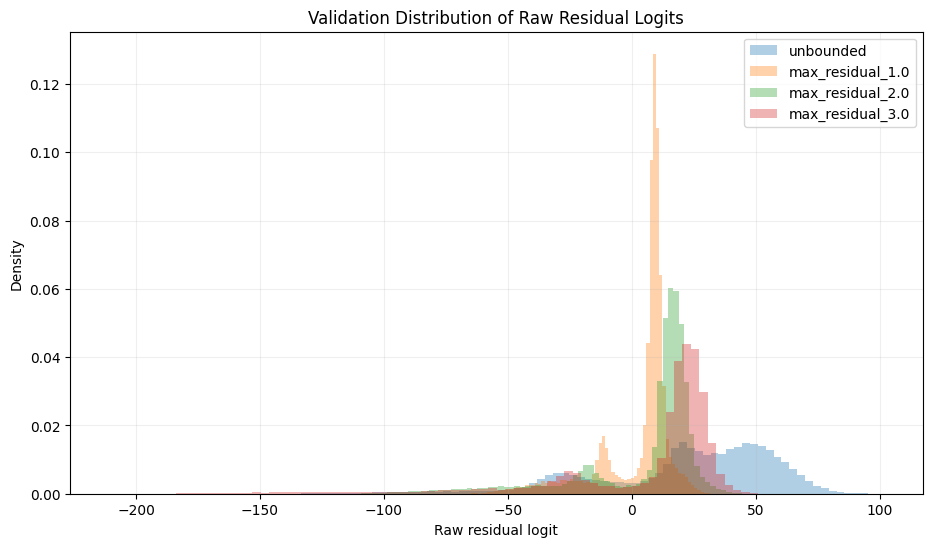

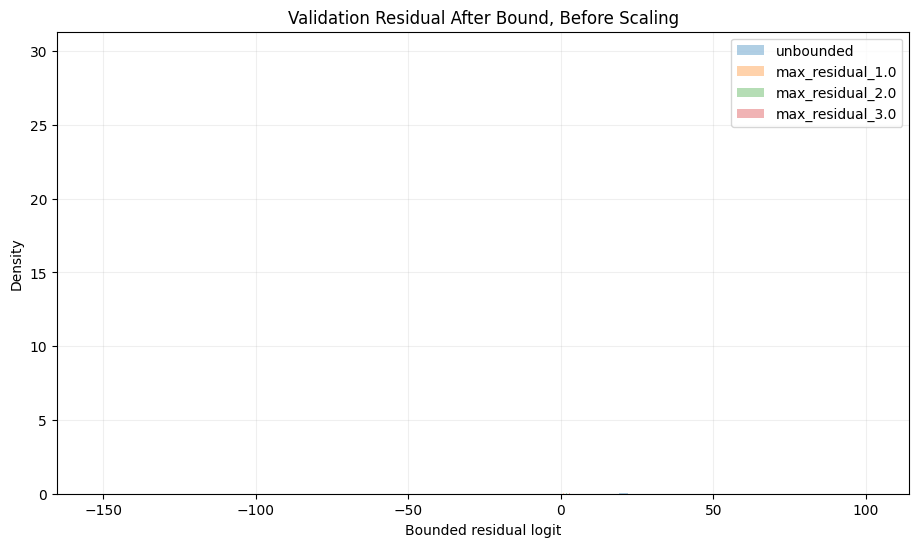

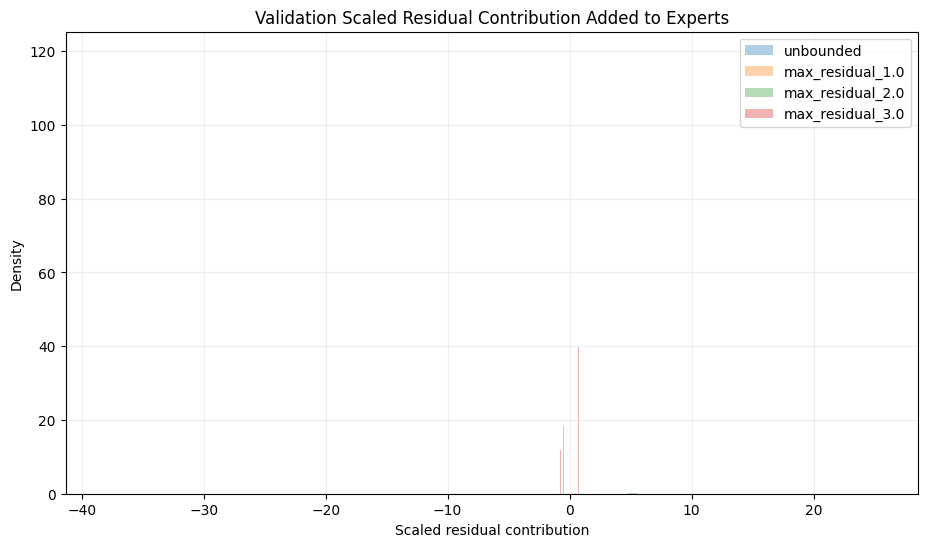

In [17]:
# CELL 17 — RESIDUAL DISTRIBUTIONS BEFORE AND AFTER BOUNDING

distribution_rows = []

for name, information in trained_variants.items():
    diagnostics = information[
        "validation_diagnostics"
    ]

    raw = diagnostics[
        "raw_residual_logit"
    ]

    bounded = diagnostics[
        "bounded_residual_logit"
    ]

    scaled = diagnostics[
        "scaled_residual_contribution"
    ]

    for distribution_name, values in (
        ("raw_residual_logit", raw),
        ("bounded_residual_logit", bounded),
        ("scaled_residual_contribution", scaled),
    ):
        distribution_rows.append({
            "variant": name,
            "distribution":
                distribution_name,
            "mean": float(
                np.mean(values)
            ),
            "std": float(
                np.std(values)
            ),
            "minimum": float(
                np.min(values)
            ),
            "p01": float(
                np.quantile(values, 0.01)
            ),
            "p05": float(
                np.quantile(values, 0.05)
            ),
            "median": float(
                np.median(values)
            ),
            "p95": float(
                np.quantile(values, 0.95)
            ),
            "p99": float(
                np.quantile(values, 0.99)
            ),
            "maximum": float(
                np.max(values)
            ),
            "mean_absolute": float(
                np.mean(np.abs(values))
            ),
        })

residual_distribution_summary = pd.DataFrame(
    distribution_rows
)

display(
    residual_distribution_summary.sort_values(
        ["distribution", "variant"]
    )
)


# Plot 1: raw residual output learned by every retrained model.
plt.figure(figsize=(11, 6))

for name, information in trained_variants.items():
    values = information[
        "validation_diagnostics"
    ]["raw_residual_logit"]

    plt.hist(
        values,
        bins=80,
        alpha=0.35,
        density=True,
        label=name,
    )

plt.title(
    "Validation Distribution of Raw Residual Logits"
)
plt.xlabel("Raw residual logit")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Plot 2: effective residual value after tanh bounding, before 0.25 scaling.
plt.figure(figsize=(11, 6))

for name, information in trained_variants.items():
    values = information[
        "validation_diagnostics"
    ]["bounded_residual_logit"]

    plt.hist(
        values,
        bins=80,
        alpha=0.35,
        density=True,
        label=name,
    )

plt.title(
    "Validation Residual After Bound, Before Scaling"
)
plt.xlabel("Bounded residual logit")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Plot 3: actual correction added to the weighted expert logit.
plt.figure(figsize=(11, 6))

for name, information in trained_variants.items():
    values = information[
        "validation_diagnostics"
    ]["scaled_residual_contribution"]

    plt.hist(
        values,
        bins=80,
        alpha=0.35,
        density=True,
        label=name,
    )

plt.title(
    "Validation Scaled Residual Contribution Added to Experts"
)
plt.xlabel(
    "Scaled residual contribution"
)
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [18]:
# CELL 18 — FINAL MULTI-SPLIT EVALUATION AND CONFIDENT FALSE POSITIVES

def report_variant(
    variant,
    split_name,
    title,
    data,
):
    model = variant["model"]
    threshold = variant["threshold"]

    (
        probabilities,
        weights,
        diagnostics,
    ) = infer_model(
        model,
        data,
    )

    current_metrics = metrics(
        data["y"],
        probabilities,
        threshold,
    )

    predictions = current_metrics["pred"]

    real_false_positive_mask = (
        (data["y"] == 0)
        & (predictions == 1)
    )

    confident_fp_95_mask = (
        real_false_positive_mask
        & (probabilities >= 0.95)
    )

    confident_fp_99_mask = (
        real_false_positive_mask
        & (probabilities >= 0.99)
    )

    print("\n" + "=" * 90)
    print(
        variant_name(
            variant["max_residual"]
        ),
        "—",
        title,
    )
    print("=" * 90)
    print("threshold:", threshold)

    for key in (
        "accuracy",
        "macro_f1",
        "real_f1",
        "fake_f1",
        "real_recall",
        "fake_recall",
        "auc",
    ):
        print(
            f"{key:<15}: "
            f"{current_metrics[key]:.4f}"
        )

    print(
        confusion_matrix(
            data["y"],
            predictions,
            labels=[0, 1],
        )
    )

    print(
        "scenario recalls:",
        scenario_recalls(
            data["y"],
            probabilities,
            threshold,
            data["scenarios"],
        ),
    )

    print(
        "mean gates:",
        weights.mean(0).round(4),
    )

    print(
        "real false positives:",
        int(
            real_false_positive_mask.sum()
        ),
    )

    print(
        "confident real FPs >= .95:",
        int(
            confident_fp_95_mask.sum()
        ),
    )

    print(
        "confident real FPs >= .99:",
        int(
            confident_fp_99_mask.sum()
        ),
    )

    if real_false_positive_mask.any():
        print(
            "mean scaled residual on real FPs:",
            float(
                diagnostics[
                    "scaled_residual_contribution"
                ][real_false_positive_mask].mean()
            ),
        )

        print(
            "max scaled residual on real FPs:",
            float(
                diagnostics[
                    "scaled_residual_contribution"
                ][real_false_positive_mask].max()
            ),
        )

        print(
            "mean weighted-expert probability on real FPs:",
            float(
                torch.sigmoid(
                    torch.from_numpy(
                        diagnostics[
                            "weighted_expert_logit"
                        ][real_false_positive_mask]
                    )
                ).mean()
            ),
        )

    row = {
        "variant":
            variant_name(
                variant["max_residual"]
            ),
        "max_residual":
            (
                np.nan
                if variant["max_residual"] is None
                else float(
                    variant["max_residual"]
                )
            ),
        "split": split_name,
        "threshold": threshold,
        **{
            key: value
            for key, value
            in current_metrics.items()
            if key != "pred"
        },
        "real_false_positives":
            int(
                real_false_positive_mask.sum()
            ),
        "confident_real_fp_95":
            int(
                confident_fp_95_mask.sum()
            ),
        "confident_real_fp_99":
            int(
                confident_fp_99_mask.sum()
            ),
        "mean_abs_raw_residual":
            float(
                np.mean(
                    np.abs(
                        diagnostics[
                            "raw_residual_logit"
                        ]
                    )
                )
            ),
        "mean_abs_bounded_residual":
            float(
                np.mean(
                    np.abs(
                        diagnostics[
                            "bounded_residual_logit"
                        ]
                    )
                )
            ),
        "mean_abs_scaled_residual":
            float(
                np.mean(
                    np.abs(
                        diagnostics[
                            "scaled_residual_contribution"
                        ]
                    )
                )
            ),
        "maximum_abs_scaled_residual":
            float(
                np.max(
                    np.abs(
                        diagnostics[
                            "scaled_residual_contribution"
                        ]
                    )
                )
            ),
    }

    gate_rows = []
    scenarios = np.asarray(
        data["scenarios"]
    )

    for scenario in sorted(
        set(scenarios)
    ):
        mask = scenarios == scenario

        gate_rows.append({
            "variant": row["variant"],
            "split": split_name,
            "scenario": scenario,
            "n": int(mask.sum()),
            "frequency":
                weights[mask, 0].mean(),
            "original_spatial":
                weights[mask, 1].mean(),
            "auxiliary_spatial":
                weights[mask, 2].mean(),
        })

    diagnostic_frame = pd.DataFrame({
        "actual": data["y"].astype(int),
        "probability": probabilities,
        "prediction": predictions,
        "scenario": data["scenarios"],
        "weighted_expert_logit":
            diagnostics[
                "weighted_expert_logit"
            ],
        "raw_residual_logit":
            diagnostics[
                "raw_residual_logit"
            ],
        "bounded_residual_logit":
            diagnostics[
                "bounded_residual_logit"
            ],
        "scaled_residual_contribution":
            diagnostics[
                "scaled_residual_contribution"
            ],
        "fused_logit":
            diagnostics[
                "fused_logit"
            ],
        "frequency_gate":
            weights[:, 0],
        "original_spatial_gate":
            weights[:, 1],
        "auxiliary_spatial_gate":
            weights[:, 2],
    })

    return (
        row,
        gate_rows,
        diagnostic_frame,
    )


evaluation_rows = []
gate_rows = []
diagnostic_frames = {}

for variant_key, variant in trained_variants.items():
    for split_name, title in (
        ("mixed_test", "MIXED HELD-OUT"),
        ("ff_test", "PURE FF++"),
        ("celeb_test", "CELEBDF ZERO-SHOT"),
        ("phone_test", "PHONE HELD-OUT"),
    ):
        data = prep(split_name)

        (
            row,
            current_gate_rows,
            diagnostic_frame,
        ) = report_variant(
            variant,
            split_name,
            title,
            data,
        )

        evaluation_rows.append(row)
        gate_rows.extend(
            current_gate_rows
        )

        diagnostic_frames[
            (variant_key, split_name)
        ] = diagnostic_frame


results = pd.DataFrame(
    evaluation_rows
)

gates = pd.DataFrame(
    gate_rows
)

display(
    results.sort_values(
        ["split", "macro_f1"],
        ascending=[True, False],
    )
)

display(gates)


# Compact comparison table.
comparison_columns = [
    "variant",
    "split",
    "threshold",
    "accuracy",
    "macro_f1",
    "real_recall",
    "fake_recall",
    "auc",
    "real_false_positives",
    "confident_real_fp_95",
    "confident_real_fp_99",
    "mean_abs_scaled_residual",
    "maximum_abs_scaled_residual",
]

display(
    results[
        comparison_columns
    ].sort_values(
        ["split", "macro_f1"],
        ascending=[True, False],
    )
)



unbounded — MIXED HELD-OUT
threshold: 0.7974999999999999
accuracy       : 0.9437
macro_f1       : 0.9407
real_f1        : 0.9274
fake_f1        : 0.9540
real_recall    : 0.9714
fake_recall    : 0.9274
auc            : 0.9899
[[5974  176]
 [ 759 9690]]
scenario recalls: {np.str_('ai_fake'): 0.9273614699971289, np.str_('clean_real'): 0.9713821138211383}
mean gates: [0.5632 0.2201 0.2167]
real false positives: 176
confident real FPs >= .95: 83
confident real FPs >= .99: 28
mean scaled residual on real FPs: 3.3023102283477783
max scaled residual on real FPs: 6.932669162750244
mean weighted-expert probability on real FPs: 0.44440117478370667

unbounded — PURE FF++
threshold: 0.7974999999999999
accuracy       : 0.9522
macro_f1       : 0.9086
real_f1        : 0.8453
fake_f1        : 0.9718
real_recall    : 0.8697
fake_recall    : 0.9668
auc            : 0.9819
[[ 3430   514]
 [  741 21591]]
scenario recalls: {np.str_('clean_real'): 0.8696754563894523, np.str_('deepfake_fake'): 0.966818914562

,variant,max_residual,split,threshold,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,real_false_positives,confident_real_fp_95,confident_real_fp_99,mean_abs_raw_residual,mean_abs_bounded_residual,mean_abs_scaled_residual,maximum_abs_scaled_residual
2,unbounded,NaN,celeb_test,0.7975,0.727433,0.687185,0.574978,0.799392,0.553100,0.814600,0.752857,4469,3796,2965,22.983950,22.983950,5.745987,19.341791
14,max_residual_3.0,3.0,celeb_test,0.6750,0.718000,0.685739,0.585050,0.786428,0.596400,0.778800,0.746701,4036,53,0,15.780223,2.907675,0.726919,0.750000
10,max_residual_2.0,2.0,celeb_test,0.6325,0.713967,0.685003,0.589485,0.780520,0.616100,0.762900,0.748514,3839,28,0,12.089167,1.957640,0.489410,0.500000
6,max_residual_1.0,1.0,celeb_test,0.5800,0.705333,0.680998,0.592889,0.769106,0.643700,0.736150,0.751983,3563,9,0,7.019259,0.978386,0.244597,0.250000
13,max_residual_3.0,3.0,ff_test,0.6750,0.954902,0.912986,0.852594,0.973379,0.868915,0.970088,0.984078,517,8,0,23.581440,2.981519,0.745380,0.750000
9,max_residual_2.0,2.0,ff_test,0.6325,0.954217,0.911808,0.850652,0.972964,0.868661,0.969327,0.983896,518,6,0,17.316874,1.990830,0.497707,0.500000
5,max_residual_1.0,1.0,ff_test,0.5800,0.953988,0.911655,0.850501,0.972810,0.871957,0.968476,0.983920,505,4,0,9.536972,0.995515,0.248879,0.250000
1,unbounded,NaN,ff_test,0.7975,0.952238,0.908553,0.845348,0.971758,0.869675,0.966819,0.981928,514,411,295,44.447750,44.447750,11.111938,27.421127
0,unbounded,NaN,mixed_test,0.7975,0.943671,0.940699,0.927424,0.953975,0.971382,0.927361,0.989872,176,83,28,27.944080,27.944080,6.986020,38.318344
12,max_residual_3.0,3.0,mixed_test,0.6750,0.940539,0.937373,0.923292,0.951453,0.965854,0.925639,0.983282,210,1,0,37.382614,2.959343,0.739836,0.750000


,variant,split,scenario,n,frequency,original_spatial,auxiliary_spatial
0,unbounded,mixed_test,ai_fake,10449,0.627686,0.187970,0.184344
1,unbounded,mixed_test,clean_real,6150,0.453698,0.274748,0.271554
2,unbounded,ff_test,clean_real,3944,0.290652,0.314582,0.394766
3,unbounded,ff_test,deepfake_fake,22332,0.331979,0.324301,0.343720
4,unbounded,celeb_test,clean_real,10000,0.272474,0.295669,0.431857
5,unbounded,celeb_test,deepfake_fake,20000,0.290151,0.305692,0.404157
6,unbounded,phone_test,phone_real,264,0.430339,0.279513,0.290148
7,max_residual_1.0,mixed_test,ai_fake,10449,0.945024,0.041605,0.013370
8,max_residual_1.0,mixed_test,clean_real,6150,0.501053,0.003862,0.495085
9,max_residual_1.0,ff_test,clean_real,3944,0.000047,0.028966,0.970987


,variant,split,threshold,accuracy,macro_f1,real_recall,fake_recall,auc,real_false_positives,confident_real_fp_95,confident_real_fp_99,mean_abs_scaled_residual,maximum_abs_scaled_residual
2,unbounded,celeb_test,0.7975,0.727433,0.687185,0.553100,0.814600,0.752857,4469,3796,2965,5.745987,19.341791
14,max_residual_3.0,celeb_test,0.6750,0.718000,0.685739,0.596400,0.778800,0.746701,4036,53,0,0.726919,0.750000
10,max_residual_2.0,celeb_test,0.6325,0.713967,0.685003,0.616100,0.762900,0.748514,3839,28,0,0.489410,0.500000
6,max_residual_1.0,celeb_test,0.5800,0.705333,0.680998,0.643700,0.736150,0.751983,3563,9,0,0.244597,0.250000
13,max_residual_3.0,ff_test,0.6750,0.954902,0.912986,0.868915,0.970088,0.984078,517,8,0,0.745380,0.750000
9,max_residual_2.0,ff_test,0.6325,0.954217,0.911808,0.868661,0.969327,0.983896,518,6,0,0.497707,0.500000
5,max_residual_1.0,ff_test,0.5800,0.953988,0.911655,0.871957,0.968476,0.983920,505,4,0,0.248879,0.250000
1,unbounded,ff_test,0.7975,0.952238,0.908553,0.869675,0.966819,0.981928,514,411,295,11.111938,27.421127
0,unbounded,mixed_test,0.7975,0.943671,0.940699,0.971382,0.927361,0.989872,176,83,28,6.986020,38.318344
12,max_residual_3.0,mixed_test,0.6750,0.940539,0.937373,0.965854,0.925639,0.983282,210,1,0,0.739836,0.750000


In [19]:
# CELL 19 — SAVE EVERY VARIANT AND SELECT THE BEST BOUNDED MODEL

all_history = pd.concat(
    training_histories.values(),
    ignore_index=True,
)

results.to_csv(
    OUTPUT_DIR
    / "bounded_residual_fusion_results.csv",
    index=False,
)

gates.to_csv(
    OUTPUT_DIR
    / "bounded_residual_fusion_gates.csv",
    index=False,
)

all_history.to_csv(
    OUTPUT_DIR
    / "bounded_residual_training_history.csv",
    index=False,
)

validation_comparison.to_csv(
    OUTPUT_DIR
    / "bounded_residual_validation_comparison.csv",
    index=False,
)

residual_distribution_summary.to_csv(
    OUTPUT_DIR
    / "bounded_residual_distribution_summary.csv",
    index=False,
)


for name, table in validation_threshold_tables.items():
    table.to_csv(
        OUTPUT_DIR
        / f"{name}_threshold_sweep.csv",
        index=False,
    )


for (
    variant_key,
    split_name,
), frame in diagnostic_frames.items():
    frame.to_csv(
        OUTPUT_DIR
        / (
            f"{variant_key}_"
            f"{split_name}_diagnostics.csv"
        ),
        index=False,
    )


for name, information in trained_variants.items():
    package = {
        "fusion_state_dict":
            information[
                "model"
            ].state_dict(),

        "threshold":
            information["threshold"],

        "temperatures":
            temperatures,

        "freq_mean":
            fm,

        "freq_std":
            fs,

        "spatial_mean":
            sm,

        "spatial_std":
            ss,

        "metadata_mean":
            meta_scaler.mean_,

        "metadata_scale":
            meta_scaler.scale_,

        "projection_dim":
            PROJECTION_DIM,

        "best_epoch":
            information["best_epoch"],

        "best_validation_score":
            information["best_score"],

        "uncertain_low":
            UNCERTAIN_LOW,

        "uncertain_high":
            UNCERTAIN_HIGH,

        "residual_scale":
            RESIDUAL_SCALE,

        "max_residual":
            information[
                "max_residual"
            ],

        "residual_bound_type":
            (
                "none"
                if information[
                    "max_residual"
                ] is None
                else (
                    "max_residual * "
                    "tanh(raw_residual / "
                    "max_residual)"
                )
            ),
    }

    checkpoint_path = (
        OUTPUT_DIR
        / f"defakex_fusion_{name}.pth"
    )

    torch.save(
        package,
        checkpoint_path,
    )

    print("Saved:", checkpoint_path)


# Rank only bounded variants by the same validation score used during training.
bounded_validation = validation_comparison[
    validation_comparison[
        "variant"
    ] != "unbounded"
].copy()

best_bounded_row = bounded_validation.iloc[0]

BEST_BOUNDED_VARIANT = str(
    best_bounded_row["variant"]
)

BEST_BOUNDED_MAX_RESIDUAL = float(
    best_bounded_row["max_residual"]
)

print("\nBest bounded variant:")
display(
    best_bounded_row.to_frame().T
)

print(
    "Selected bounded model:",
    BEST_BOUNDED_VARIANT,
)

print(
    "Selected MAX_RESIDUAL:",
    BEST_BOUNDED_MAX_RESIDUAL,
)


# Acceptance-gate report for every variant.
acceptance_rows = []

for variant_key in trained_variants:
    variant_results = (
        results[
            results["variant"]
            == variant_key
        ]
        .set_index("split")
    )

    checks = {
        "FF++ macro-F1 >= .90":
            variant_results.loc[
                "ff_test",
                "macro_f1",
            ] >= 0.90,

        "FF++ real recall >= .88":
            variant_results.loc[
                "ff_test",
                "real_recall",
            ] >= 0.88,

        "FF++ fake recall >= .92":
            variant_results.loc[
                "ff_test",
                "fake_recall",
            ] >= 0.92,

        "CelebDF AUC >= .76":
            variant_results.loc[
                "celeb_test",
                "auc",
            ] >= 0.76,

        "CelebDF real recall >= .70":
            variant_results.loc[
                "celeb_test",
                "real_recall",
            ] >= 0.70,

        "CelebDF fake recall >= .70":
            variant_results.loc[
                "celeb_test",
                "fake_recall",
            ] >= 0.70,

        "Phone real recall >= .80":
            variant_results.loc[
                "phone_test",
                "real_recall",
            ] >= 0.80,
    }

    acceptance_rows.append({
        "variant": variant_key,
        "passed": sum(
            checks.values()
        ),
        "total": len(checks),
        **checks,
    })


acceptance = pd.DataFrame(
    acceptance_rows
)

display(acceptance)

acceptance.to_csv(
    OUTPUT_DIR
    / "bounded_residual_acceptance_gates.csv",
    index=False,
)

print(
    "\nAll outputs saved under:",
    OUTPUT_DIR,
)


Saved: /kaggle/working/defakex_fusion_unbounded.pth
Saved: /kaggle/working/defakex_fusion_max_residual_1.0.pth
Saved: /kaggle/working/defakex_fusion_max_residual_2.0.pth
Saved: /kaggle/working/defakex_fusion_max_residual_3.0.pth

Best bounded variant:


,variant,max_residual,threshold,best_epoch,best_validation_score,score,accuracy,macro_f1,real_f1,fake_f1,real_recall,fake_recall,auc,worst_scenario,recall_ai_fake,recall_clean_real,recall_deepfake_fake,recall_phone_real
3,max_residual_3.0,3.0,0.675,14,0.881422,0.881422,0.948319,0.930515,0.895342,0.965688,0.931851,0.953441,0.979879,0.93167,0.932114,0.93167,0.962966,0.938931


Selected bounded model: max_residual_3.0
Selected MAX_RESIDUAL: 3.0


,variant,passed,total,FF++ macro-F1 >= .90,FF++ real recall >= .88,FF++ fake recall >= .92,CelebDF AUC >= .76,CelebDF real recall >= .70,CelebDF fake recall >= .70,Phone real recall >= .80
0,unbounded,4,7,True,False,True,False,False,True,True
1,max_residual_1.0,4,7,True,False,True,False,False,True,True
2,max_residual_2.0,4,7,True,False,True,False,False,True,True
3,max_residual_3.0,4,7,True,False,True,False,False,True,True



All outputs saved under: /kaggle/working


In [20]:
# CELL 20 — DECISION TABLE FOR SUPERVISOR REVIEW

# This table focuses on the trade-off requested by the supervisor:
# preserve useful correction power while reducing confident false positives.

decision_table = (
    results.groupby("variant")
    .agg(
        mean_macro_f1=(
            "macro_f1",
            "mean",
        ),
        minimum_macro_f1=(
            "macro_f1",
            "min",
        ),
        mean_real_recall=(
            "real_recall",
            "mean",
        ),
        mean_fake_recall=(
            "fake_recall",
            "mean",
        ),
        total_real_false_positives=(
            "real_false_positives",
            "sum",
        ),
        total_confident_real_fp_95=(
            "confident_real_fp_95",
            "sum",
        ),
        total_confident_real_fp_99=(
            "confident_real_fp_99",
            "sum",
        ),
        mean_abs_scaled_residual=(
            "mean_abs_scaled_residual",
            "mean",
        ),
        maximum_abs_scaled_residual=(
            "maximum_abs_scaled_residual",
            "max",
        ),
    )
    .reset_index()
)

decision_table = decision_table.merge(
    validation_comparison[
        [
            "variant",
            "best_validation_score",
            "threshold",
            "max_residual",
        ]
    ],
    on="variant",
    how="left",
)

decision_table["confident_fp_95_reduction_vs_unbounded"] = (
    decision_table.loc[
        decision_table["variant"]
        == "unbounded",
        "total_confident_real_fp_95",
    ].iloc[0]
    - decision_table[
        "total_confident_real_fp_95"
    ]
)

decision_table["confident_fp_99_reduction_vs_unbounded"] = (
    decision_table.loc[
        decision_table["variant"]
        == "unbounded",
        "total_confident_real_fp_99",
    ].iloc[0]
    - decision_table[
        "total_confident_real_fp_99"
    ]
)

display(
    decision_table.sort_values(
        [
            "best_validation_score",
            "total_confident_real_fp_95",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

decision_table.to_csv(
    OUTPUT_DIR
    / "bounded_residual_decision_table.csv",
    index=False,
)

print(
    "Use this table together with the residual-distribution plots. "
    "Do not select MAX_RESIDUAL from one metric alone."
)


,variant,mean_macro_f1,minimum_macro_f1,mean_real_recall,mean_fake_recall,total_real_false_positives,total_confident_real_fp_95,total_confident_real_fp_99,mean_abs_scaled_residual,maximum_abs_scaled_residual,best_validation_score,threshold,max_residual,confident_fp_95_reduction_vs_unbounded,confident_fp_99_reduction_vs_unbounded
3,unbounded,0.756202,0.488372,0.837176,0.677195,5171,4295,3292,8.725430,38.318344,0.883442,0.7975,NaN,0,0
2,max_residual_3.0,0.756118,0.488372,0.846428,0.668632,4775,62,0,0.735415,0.750000,0.881422,0.6750,3.0,4233,3292
1,max_residual_2.0,0.754172,0.486381,0.848095,0.663772,4613,35,0,0.492096,0.500000,0.878652,0.6325,2.0,4260,3292
0,max_residual_1.0,0.750931,0.482353,0.850324,0.656083,4370,13,0,0.246707,0.250000,0.876531,0.5800,1.0,4282,3292


Use this table together with the residual-distribution plots. Do not select MAX_RESIDUAL from one metric alone.
